# Isolated test for Quantum Builders (Square Grid)
This section builds a 2D pure grid manually (without `System` or `poisson` generation). Then it immediately invokes either `kwant_solver` or `default_solver`.

In [1]:
import os
import sys
sys.path.append(os.getcwd()+"/Equantum")
import numpy as np
import matplotlib.pyplot as plt
import importlib
%matplotlib inline

from quantum_solvers.default_solver import QuantumSystem
from quantum_solvers import kwant_solver
from quantum_solvers.kpm_solver import kpm_ldos, kpm_dos


## 1. Mocking the System Class
We need to mock out the bare minimum that `QuantumSystem` and `kwant_builder` look for to function on a direct 2D list of Sites.

In [2]:
class MockSite:
    def __init__(self, idx, coords):
        self.id = idx
        self.coordinates = coords
        self.pos = coords  # kwant specifically uses .pos sometimes
        self.neighbors = {} # map of neighbor_idx -> direction/distance obj
        self.material = 'Qsystem'

class MockSystem:
    def __init__(self, L=10, W=10, a=1.0):
        self.L = L
        self.W = W
        self.lat_spacing = a
        self.t = 1.0
        self.geometry_params = {'lattice_type': 'square', 'sampling_density_function': lambda z: a}
        
        self.sites = {}  # Keep the full dict
        self.Qsites = [] # List of IDs
        
        self._build_grid()
        
    def _build_grid(self):
        grid = np.zeros((self.L, self.W), dtype=int)
        # Create Sites
        count = 0
        for x in range(self.L):
            for y in range(self.W):
                coords = [x * self.lat_spacing, y * self.lat_spacing, 0.0]
                site = MockSite(count, coords)
                self.sites[count] = site
                self.Qsites.append(count)
                grid[x, y] = count
                count += 1
                
        # Assign Neighbors (Square Grid)
        for x in range(self.L):
            for y in range(self.W):
                idx = grid[x, y]
                nhbrs = []
                if x > 0: nhbrs.append(grid[x-1, y])
                if x < self.L - 1: nhbrs.append(grid[x+1, y])
                if y > 0: nhbrs.append(grid[x, y-1])
                if y < self.W - 1: nhbrs.append(grid[x, y+1])
                
                # Fill neighbor dictionary with dummy distances
                for n in nhbrs:
                    self.sites[idx].neighbors[n] = self.lat_spacing


## 2. Test Kwant Solver
Check `kwant_solver.kwant_builder()` on the identical object.

In [3]:
print("Generating MOCK System (20x20) grid...")
mock_syst = MockSystem(L=20, W=20)
qparams = {'Ufunc': lambda site: 0.0, 'phi': 0.08}

print("Testing Kwant Solver Construction...")
kw_syst = kwant_solver.kwant_builder(mock_syst)

def Ufunc(site): return 0.0
# Setting system params as parsed by Kwant
kw_params = {'Ufunc': Ufunc, 'phi': qparams['phi']}

print("Evaluating via Kwant KPM Model...")
import kwant
spectrum_kpm = kwant.kpm.SpectralDensity(kw_syst, params=kw_params, energy_resolution=0.02)
energies_kw, dos_kw = spectrum_kpm()
print("Done.")

Generating MOCK System (20x20) grid...
Testing Kwant Solver Construction...


100%|██████████| 400/400 [00:00<00:00, 3652.83it/s]

Evaluating via Kwant KPM Model...
Done.


## 3. Test Default Solver
Ensure `default_solver` functions seamlessly on the isolated mesh.

In [4]:
print("Testing Default Solver Construction...")
def_solver = QuantumSystem(mock_syst, params=qparams)
print(f"Hamiltonian built successfully. Shape: {def_solver.H.shape}")

print("Evaluating via Default KPM Solver...")
energies_def, dos_def = def_solver.get_dos(
    params=qparams,
    i=None,
    w=energies_kw,
    M=256,
    n_random=54,
    eps=0.05,
    kernel="jackson",
)
print("Done.")

Testing Default Solver Construction...
Hamiltonian built successfully. Shape: (400, 400)
Evaluating via Default KPM Solver...
Done.


## 4. Compare Spectrum by Exact Diagonalization
Extract the complete Hamiltonian matrices and diagonalize them to ensure the spectrum matches exactly.

Diagonalizing Default Hamiltonian...
Diagonalizing Kwant Hamiltonian...


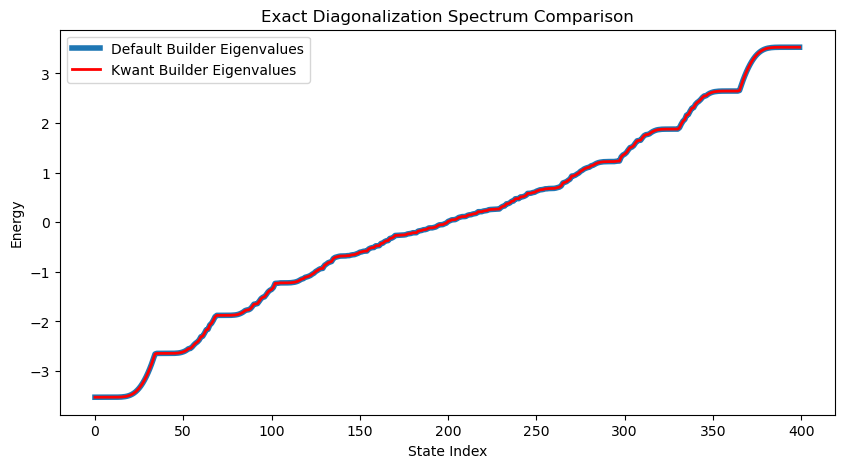

In [5]:
import scipy.linalg as sl
print("Diagonalizing Default Hamiltonian...")
H_def = def_solver.H.toarray()
eig_def = sl.eigh(H_def, eigvals_only=True)

print("Diagonalizing Kwant Hamiltonian...")
H_kw = kw_syst.hamiltonian_submatrix(params=kw_params)
eig_kw = sl.eigh(H_kw, eigvals_only=True)

plt.figure(figsize=(10, 5))
plt.plot(eig_def, label='Default Builder Eigenvalues', lw=4)
plt.plot(np.sort(eig_kw), label='Kwant Builder Eigenvalues', ls='-', c='r', lw=2)
plt.xlabel('State Index')
plt.ylabel('Energy')
plt.title('Exact Diagonalization Spectrum Comparison')
plt.legend()
plt.show()

## 5. Visual Cross-Plot (DOS)

In [6]:
H_exact = def_solver.get_hamiltonian().toarray()
evals = np.linalg.eigvalsh(H_exact)

def gaussian_broadened_dos(evals, energies, eta=0.02):
    rho = np.zeros_like(energies, dtype=float)
    pref = 1.0 / (np.sqrt(2 * np.pi) * eta)
    for ev in evals:
        rho += pref * np.exp(-0.5 * ((energies - ev) / eta)**2)
    return rho

dos_exact = gaussian_broadened_dos(evals, energies_kw, eta=0.02)

/scratch/zhaoyuha/miniconda3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


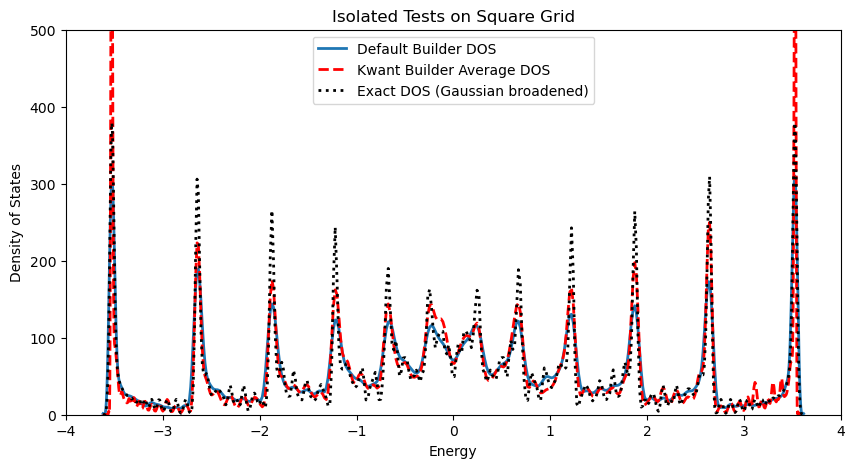

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(energies_def, dos_def, label='Default Builder DOS', lw=2)
#plt.plot(energies_det, dos_det, label='Default Builder DOS from LDOS', lw=2)
plt.plot(energies_kw, dos_kw, label='Kwant Builder Average DOS', ls='--', c='r', lw=2)
plt.plot(energies_kw, dos_exact, label='Exact DOS (Gaussian broadened)', ls=':', c='k', lw=2)

plt.xlabel('Energy')
plt.ylabel('Density of States')
plt.title('Isolated Tests on Square Grid')
plt.xlim(-4,4)
plt.ylim(0,500)
plt.legend()
plt.show()

In [13]:
dos_def_n = dos_def / np.max(np.abs(dos_def))
dos_kw_n = dos_kw / np.max(np.abs(dos_kw))

print("Shape max diff:", np.max(np.abs(dos_def_n - dos_kw_n)))
print("Shape RMS diff:", np.sqrt(np.mean(np.abs(dos_def_n - dos_kw_n)**2)))

Shape max diff: 0.15956454304556322
Shape RMS diff: 0.025948318677615583


In [19]:
from quantum_solvers.kpm_solver import kpm_dos_from_ldos

energies_det, dos_det = kpm_dos_from_ldos(
    def_solver.get_hamiltonian(),
    energies=energies_kw,
    num_moments=256,
    eps=0.05,
)

In [12]:
from quantum_solvers.kpm_solver import kpm_ldos
H = def_solver.get_hamiltonian()
energies = energies_kw

dos_from_ldos = np.zeros_like(energies, dtype=float)
for i in range(def_solver.N):
    _, rho_i = kpm_ldos(H, site_index=i, energies=energies, M=1024)
    dos_from_ldos += rho_i

In [11]:
print("Integral default:", np.trapz(dos_def, energies_def).real)
print("Integral kwant:  ", np.trapz(dos_kw, energies_kw).real)
print("Integral exact:  ", np.trapz(dos_exact, energies_kw).real)
print("N:", def_solver.N)

Integral default: 399.9978833410372
Integral kwant:   399.9982200789135
Integral exact:   399.9981881371246
N: 400


In [16]:
import numpy as np
import kwant

print("Generating MOCK System (20x20) grid...")
mock_syst = MockSystem(L=20, W=20)
qparams = {'Ufunc': lambda site: 0.0, 'phi': 0.05}

print("Testing Default Solver Construction...")
def_solver = QuantumSystem(mock_syst, params=qparams)
print(f"Hamiltonian built successfully. Shape: {def_solver.H.shape}")

print("Testing Kwant Solver Construction...")
kw_syst = kwant_solver.kwant_builder(mock_syst)

def Ufunc(site):
    return 0.0

kw_params = {'Ufunc': Ufunc, 'phi': qparams['phi']}

print("Evaluating via Kwant KPM Model...")
spectrum_kpm = kwant.kpm.SpectralDensity(
    kw_syst,
    params=kw_params,
    energy_resolution=0.02
)
energies_kw, dos_kw = spectrum_kpm()
print("Kwant done.")

print("Evaluating via Default KPM Solver...")
energies_def, dos_def = def_solver.get_dos(
    params=qparams,
    i=None,
    w=energies_kw,
    M=1024,
    n_random=16
)
print("Default solver done.")

dos_kw_norm = dos_kw / np.trapz(dos_kw, energies_kw)
dos_def_norm = dos_def / np.trapz(dos_def, energies_def)

diff = dos_kw_norm - dos_def_norm
max_abs_diff = np.max(np.abs(diff))
rms_diff = np.sqrt(np.mean(np.abs(diff)**2))

print(f"Max abs difference: {max_abs_diff:.6e}")
print(f"RMS difference:     {rms_diff:.6e}")

Generating MOCK System (20x20) grid...
Testing Default Solver Construction...
Hamiltonian built successfully. Shape: (400, 400)
Testing Kwant Solver Construction...


100%|██████████| 400/400 [00:00<00:00, 3681.40it/s]


Evaluating via Kwant KPM Model...
Kwant done.
Evaluating via Default KPM Solver...
Default solver done.
Max abs difference: 1.076266e+01
RMS difference:     4.660617e-01


In [26]:
import numpy as np

H_def = def_solver.get_hamiltonian().toarray()
H_kw = kw_syst.hamiltonian_submatrix(params=kw_params, sparse=False)

# default basis: coordinate -> index
def_coord_to_idx = {
    tuple(np.round(np.array(site.coordinates[:2]), 12)): i
    for i, site in enumerate(def_solver.Qsites)
}

# for each kwant site index k, find which default index it corresponds to
kw_to_def = []
for ks in kw_syst.sites:
    pos = tuple(np.round(np.array(ks.pos), 12))
    kw_to_def.append(def_coord_to_idx[pos])

kw_to_def = np.array(kw_to_def)

# permutation to reorder Kwant basis into default basis
perm = np.argsort(kw_to_def)
H_kw_reordered = H_kw[np.ix_(perm, perm)]

print("H max abs diff:", np.max(np.abs(H_def - H_kw_reordered)))
print("H RMS diff:", np.sqrt(np.mean(np.abs(H_def - H_kw_reordered)**2)))

H max abs diff: 0.0
H RMS diff: 0.0


In [27]:
import numpy as np

def exact_ldos(H, site_index, energies, eta=0.02):
    evals, evecs = np.linalg.eigh(H)
    weights = np.abs(evecs[site_index, :])**2

    rho = np.zeros_like(energies, dtype=float)
    pref = 1.0 / (np.sqrt(2 * np.pi) * eta)

    for n, ev in enumerate(evals):
        rho += weights[n] * pref * np.exp(-(energies - ev)**2 / (2 * eta**2))

    return rho

def exact_dos(H, energies, eta=0.02):
    evals = np.linalg.eigvalsh(H)
    rho = np.zeros_like(energies, dtype=float)
    pref = 1.0 / (np.sqrt(2 * np.pi) * eta)

    for ev in evals:
        rho += pref * np.exp(-(energies - ev)**2 / (2 * eta**2))

    return rho

In [ ]:

H = def_solver.get_hamiltonian().toarray()
energies = np.linspace(-4, 4, 400)
site_index = def_solver.N // 2

rho_exact = exact_ldos(H, site_index, energies, eta=0.02)
_, rho_kpm = kpm_ldos(def_solver.get_hamiltonian(), site_index, energies, M=1024)

rho_exact /= np.max(np.abs(rho_exact))
rho_kpm /= np.max(np.abs(rho_kpm))

print("LDOS max diff:", np.max(np.abs(rho_exact - rho_kpm)))
print("LDOS RMS diff:", np.sqrt(np.mean(np.abs(rho_exact - rho_kpm)**2)))

LDOS max diff: 0.39411303287673854
LDOS RMS diff: 0.09493208262477791


In [ ]:
H = def_solver.get_hamiltonian()

# your solver
energies_my, dos_my = kpm_dos(
    H,
    num_moments=512,
    num_vectors=10,
    eps=0.05,
    kernel="jackson",
    rng=1234
)

# kwant on the same matrix
rho_kw = kwant.kpm.SpectralDensity(
    H,
    num_moments=512,
    num_vectors=10,
    eps=0.05,
    rng=1234
)
energies_kw, dos_kw = rho_kw(energies_my)